<a href="https://colab.research.google.com/github/jameshdugulu/machine_learning_Classification/blob/main/Classification_Beginner_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# 🏦 Classification & Model Evaluation — Beginner Lab
### *Can we predict if a loan application will be Approved or Rejected?*
#### Dataset: Bank Loan Applications in Rwanda

---

## What Is Classification?

**Classification** is a type of machine learning where we predict a **category** (not a number).

Instead of predicting *"how much?"* (that was regression), classification predicts *"which group?"*:

| Question | Answer type | Type of ML |
|----------|------------|------------|
| What will this house sell for? | A number (45M RWF) | **Regression** |
| Will this loan be approved? | A category (Yes / No) | **Classification** |
| Is this email spam? | A category (Spam / Not Spam) | **Classification** |
| What disease does this patient have? | A category (Flu / Cold / Malaria) | **Classification** |
| Will this customer leave us next month? | A category (Yes / No) | **Classification** |

---

## Our Task

> 🏦 **Imagine you are a loan officer at a Rwandan bank.**  
> Every day, hundreds of people apply for loans.  
> For each applicant, you have information: their income, credit score, employment history, loan amount requested, etc.  
> Your job is to decide: **Approve or Reject?**
>
> You have historical data from 300 past applications where you already know the final decision.  
> We will train a model to **learn the pattern** from past decisions, so it can help make future ones.

---

## What You Will Learn

| Step | What we do |
|------|------------|
| **Step 1** | Load and explore the loan applications dataset |
| **Step 2** | Understand which features separate Approved from Rejected |
| **Step 3** | Build a K-Nearest Neighbours (KNN) classifier |
| **Step 4** | Build a Decision Tree classifier |
| **Step 5** | Evaluate both models — Accuracy, Confusion Matrix, Precision, Recall |
| **Step 6** | Predict the outcome for a new loan application |

---
> ⏱️ **Time:** About 2.5–3 hours &nbsp;|&nbsp; **Level:** Beginner &nbsp;|&nbsp; **No advanced math required**
---

---
## ⚙️ Setup — Run This Cell First!

We need:
- `pandas` → organises our data
- `matplotlib` → draws charts
- `sklearn` → the machine learning library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
---
# STEP 1: Load and Explore the Dataset

Our dataset has **300 loan applications** from a Rwandan bank.  
Each row is one customer who applied for a loan.  
We already know if their application was approved or rejected.

In [ ]:
# Load the dataset
df = pd.read_csv('loan_applications.csv')

print('Dataset loaded!')
print('Rows    :', df.shape[0])
print('Columns :', df.shape[1])

Dataset loaded!
Rows    : 300
Columns : 12


In [ ]:
# Look at the first 8 rows
df.head(8)

,CustomerID,Age,MonthlyIncome,LoanAmount,EmployedYears,CreditScore,Dependants,HasSavings,LoanPurpose,LoanToIncome,Approved,ApprovalStatus
0,1,50,615017,2371403,5,757,2,0,Education,0.321,1,Approved
1,2,36,256089,6247372,2,461,3,1,Education,2.033,0,Rejected
2,3,29,277392,5348287,18,679,0,1,Home,1.607,0,Rejected
3,4,42,238823,6158796,14,386,2,0,Business,2.149,0,Rejected
4,5,40,710152,1321052,4,354,2,0,Personal,0.155,1,Approved
5,6,44,473002,2307150,9,775,0,0,Home,0.406,1,Approved
6,7,32,578863,2725300,6,477,4,1,Education,0.392,1,Approved
7,8,32,447654,2355567,16,690,2,1,Personal,0.439,1,Approved


### What Each Column Means

| Column | Meaning | Example |
|--------|---------|--------|
| `CustomerID` | Unique ID for each applicant | 1, 2, 3 |
| `Age` | Age of the applicant | 35 |
| `MonthlyIncome` | Monthly salary in RWF | 450,000 |
| `LoanAmount` | How much they want to borrow (RWF) | 2,000,000 |
| `EmployedYears` | How many years they have been employed | 7 |
| `CreditScore` | Credit history score (300 = poor, 850 = excellent) | 680 |
| `Dependants` | Number of people depending on them financially | 2 |
| `HasSavings` | 1 = has a savings account, 0 = does not | 1 |
| `LoanPurpose` | Why they need the loan | Home, Business |
| `LoanToIncome` | Loan amount ÷ annual income (lower = safer) | 0.45 |
| `Approved` | **Our target** — 1 = loan was approved, 0 = rejected | 1 |
| `ApprovalStatus` | Same as Approved but as text | Approved / Rejected |

---

**In classification language:**
- The column we want to **predict** is the **target (y)** — this is `Approved` (0 or 1)
- The columns we use to **make the prediction** are the **features (X)** — Income, CreditScore, etc.
- The two possible outcomes (Approved / Rejected) are called **classes**

In [ ]:
# How many were approved vs rejected?
counts = df['ApprovalStatus'].value_counts()
print('Approval breakdown:')
print(counts)
print()

approved_pct = df['Approved'].mean() * 100
print(f'Approval rate: {approved_pct:.1f}%')
print(f'Rejection rate: {100 - approved_pct:.1f}%')

Approval breakdown:
ApprovalStatus
Rejected    151
Approved    149
Name: count, dtype: int64

Approval rate: 49.7%
Rejection rate: 50.3%


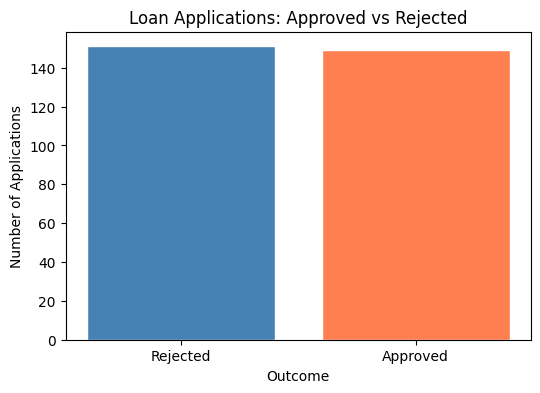

In [ ]:
# Bar chart showing Approved vs Rejected
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=['steelblue', 'coral'], edgecolor='white')
plt.title('Loan Applications: Approved vs Rejected')
plt.xlabel('Outcome')
plt.ylabel('Number of Applications')
plt.show()

### 💡 Why Balanced Classes Matter

Our dataset has almost **equal numbers** of Approved and Rejected.  
This is ideal for classification.

> ⚠️ **What if it were NOT balanced?**  
> Imagine 95% of loans are approved and only 5% rejected.  
> A lazy model could just predict "Approved" for EVERY application and get 95% accuracy!  
> But it would be completely useless — it would miss every single rejection.  
> This is called the **class imbalance problem**. Balanced data avoids it.

---
### ✏️ YOUR TURN — Step 1

1. Run `df.describe()` and find the average `CreditScore` across all applicants.
2. What is the average `MonthlyIncome` across all applicants?
3. How many applicants have a savings account (`HasSavings == 1`)?

In [ ]:
# Task 1 and 2: df.describe()


# Task 3: Count those with savings


---
---
# STEP 2: Understand What Separates Approved From Rejected

Before building any model, we explore the data to find which features are **different**  
between approved and rejected applicants.

> 💡 **Key idea:** Features where approved and rejected groups look **very different**  
> will be the most useful features for our model to learn from.

## 2.1 Average Values: Approved vs Rejected

In [ ]:
# Compare average values of key features for Approved vs Rejected
numeric_features = ['Age', 'MonthlyIncome', 'LoanAmount', 'EmployedYears',
                    'CreditScore', 'Dependants', 'LoanToIncome']

comparison = df.groupby('ApprovalStatus')[numeric_features].mean().round(1)
print('Average values — Approved vs Rejected:')
print(comparison.T)   # .T = transpose, makes it easier to read

Average values — Approved vs Rejected:
ApprovalStatus   Approved   Rejected
Age                  41.7       40.7
MonthlyIncome    553269.9   305567.4
LoanAmount      3638552.8  4936628.1
EmployedYears         9.3        8.9
CreditScore         619.5      512.2
Dependants            2.0        2.0
LoanToIncome          0.6        1.8


### 💡 Reading This Table

Look at each row and ask: *"Is there a big difference between Approved and Rejected?"*

- **CreditScore** — if approved applicants have much higher scores → very useful feature!
- **MonthlyIncome** — if approved applicants earn more → very useful feature!
- **LoanToIncome** — if approved applicants have a lower ratio → very useful feature!
- **Age / Dependants** — if both groups look similar → less useful for the model

## 2.2 Credit Score Distribution: Approved vs Rejected

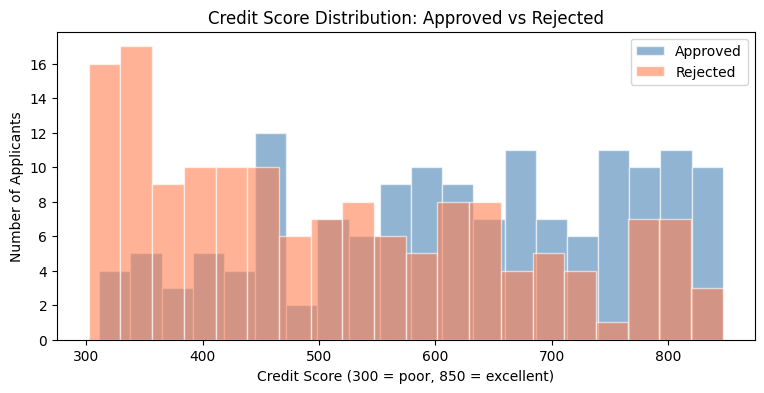

Average Credit Score — Approved: 620
Average Credit Score — Rejected: 512


In [ ]:
# Separate the two groups
approved = df[df['Approved'] == 1]['CreditScore']
rejected = df[df['Approved'] == 0]['CreditScore']

plt.figure(figsize=(9, 4))
plt.hist(approved, bins=20, color='steelblue', alpha=0.6, label='Approved', edgecolor='white')
plt.hist(rejected, bins=20, color='coral',     alpha=0.6, label='Rejected', edgecolor='white')
plt.title('Credit Score Distribution: Approved vs Rejected')
plt.xlabel('Credit Score (300 = poor, 850 = excellent)')
plt.ylabel('Number of Applicants')
plt.legend()
plt.show()

print(f'Average Credit Score — Approved: {approved.mean():.0f}')
print(f'Average Credit Score — Rejected: {rejected.mean():.0f}')

### 💡 Reading This Chart

- The **blue bars (Approved)** are shifted to the **right** — approved applicants tend to have higher credit scores
- The **red bars (Rejected)** are shifted to the **left** — rejected applicants tend to have lower credit scores
- But there is **overlap** in the middle — some rejected applicants had good scores, and some approved had low scores

> This overlap is exactly why we need a machine learning model — the rules are not simple enough to be 100% clear-cut.

## 2.3 Monthly Income: Approved vs Rejected

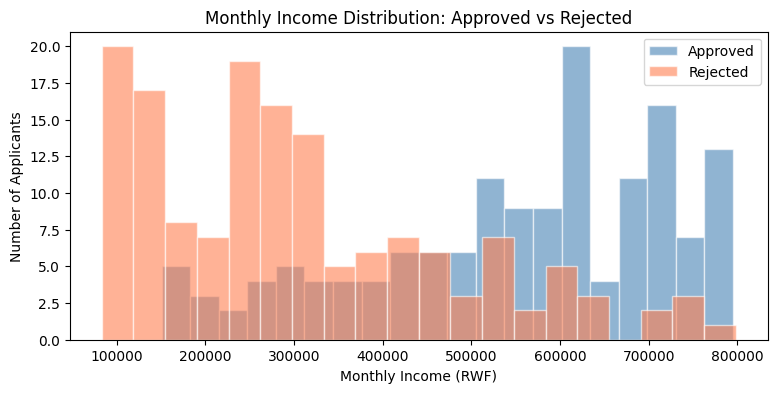

Average Income — Approved: 553,270 RWF
Average Income — Rejected: 305,567 RWF


In [ ]:
approved_income = df[df['Approved'] == 1]['MonthlyIncome']
rejected_income = df[df['Approved'] == 0]['MonthlyIncome']

plt.figure(figsize=(9, 4))
plt.hist(approved_income, bins=20, color='steelblue', alpha=0.6, label='Approved', edgecolor='white')
plt.hist(rejected_income, bins=20, color='coral',     alpha=0.6, label='Rejected', edgecolor='white')
plt.title('Monthly Income Distribution: Approved vs Rejected')
plt.xlabel('Monthly Income (RWF)')
plt.ylabel('Number of Applicants')
plt.legend()
plt.show()

print(f'Average Income — Approved: {approved_income.mean():,.0f} RWF')
print(f'Average Income — Rejected: {rejected_income.mean():,.0f} RWF')

## 2.4 Loan Purpose Approval Rates

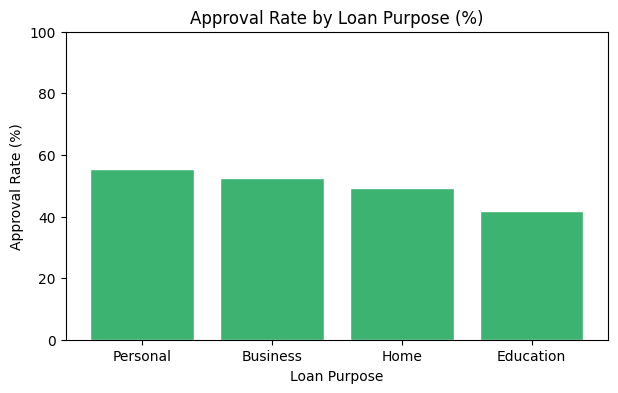

Approval rate by purpose:
  Personal     : 55.3%
  Business     : 52.6%
  Home         : 49.1%
  Education    : 41.8%


In [ ]:
# What percentage of applications were approved for each loan purpose?
purpose_approval = df.groupby('LoanPurpose')['Approved'].mean() * 100
purpose_approval = purpose_approval.sort_values(ascending=False).round(1)

plt.figure(figsize=(7, 4))
plt.bar(purpose_approval.index, purpose_approval.values, color='mediumseagreen', edgecolor='white')
plt.title('Approval Rate by Loan Purpose (%)')
plt.xlabel('Loan Purpose')
plt.ylabel('Approval Rate (%)')
plt.ylim(0, 100)
plt.show()

print('Approval rate by purpose:')
for purpose, rate in purpose_approval.items():
    print(f'  {purpose:<12} : {rate:.1f}%')

## 2.5 Credit Score vs Income — Scatter Plot (Coloured by Outcome)

A scatter plot with **colour-coding** is a powerful way to see if two features together  
separate the two classes visually.

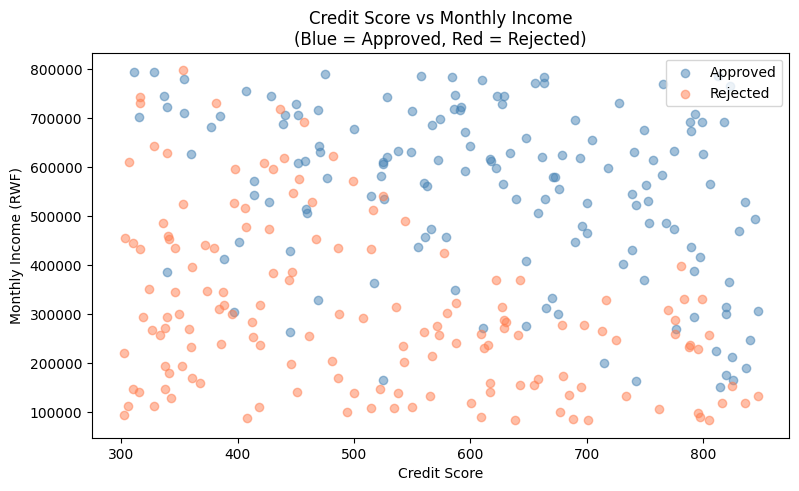

In [ ]:
approved_df = df[df['Approved'] == 1]
rejected_df = df[df['Approved'] == 0]

plt.figure(figsize=(9, 5))
plt.scatter(approved_df['CreditScore'], approved_df['MonthlyIncome'],
            color='steelblue', alpha=0.5, label='Approved')
plt.scatter(rejected_df['CreditScore'], rejected_df['MonthlyIncome'],
            color='coral', alpha=0.5, label='Rejected')

plt.title('Credit Score vs Monthly Income\n(Blue = Approved, Red = Rejected)')
plt.xlabel('Credit Score')
plt.ylabel('Monthly Income (RWF)')
plt.legend()
plt.show()

### 💡 Reading This Chart

- **Blue dots (Approved)** tend to appear in the **top-right** — higher credit score AND higher income
- **Red dots (Rejected)** tend to appear in the **bottom-left** — lower credit score AND lower income
- The **middle area** has a mix — these are the difficult cases where a human (or model) might be uncertain

> This is exactly what classification models do — they find an invisible boundary line  
> separating the blue region from the red region. When a new application arrives,  
> they check which side of that boundary the applicant falls on.

---
### ✏️ YOUR TURN — Step 2

1. Draw overlapping histograms comparing `LoanToIncome` for Approved vs Rejected.  
   (Use the same pattern as the Credit Score chart above — just change the column name.)

2. Calculate the approval rate for applicants **with** savings vs **without** savings:  
   `df.groupby('HasSavings')['Approved'].mean() * 100`

3. Which group has higher average `EmployedYears` — Approved or Rejected?  
   `df.groupby('ApprovalStatus')['EmployedYears'].mean()`

In [ ]:
# Task 1: Histogram of LoanToIncome — Approved vs Rejected



# Task 2: Approval rate with/without savings


# Task 3: Average employment years by outcome


---
---
# STEP 3: K-Nearest Neighbours (KNN) Classifier

## What Is KNN?

KNN is one of the **simplest and most intuitive** machine learning algorithms.  
The idea is surprisingly simple:

> 🏦 **The idea in plain English:**  
> A new loan application arrives.  
> We look at the **K most similar** past applications in our dataset.  
> We see what happened to those similar applicants — were they approved or rejected?  
> We go with the **majority vote**.
>
> If K = 5, we find the 5 most similar past applicants.  
> If 4 of them were approved → we predict Approved.  
> If 3 of them were rejected → we predict Rejected.

"Similar" is measured by how close applicants are in terms of their feature values  
(income, credit score, loan amount, etc.).

---

## Why Do We Need Scaling for KNN?

> ⚠️ **Important!** KNN uses distance to find similar applicants.  
> Income ranges from 80,000 to 800,000.  
> Credit score ranges from 300 to 850.  
> Without scaling, income differences would completely DOMINATE because the numbers are so much bigger.  
> A difference of 10 in credit score and 100,000 in income would make income seem 10,000× more important — which is wrong!
>
> **We must standardise all features before using KNN.**  
> Standardisation makes every feature have the same scale (mean = 0, std = 1).

In [ ]:
# Step 1: Choose our features and target
feature_columns = ['CreditScore', 'MonthlyIncome', 'LoanAmount',
                   'EmployedYears', 'LoanToIncome', 'HasSavings', 'Dependants']

X = df[feature_columns]
y = df['Approved']      # 1 = Approved, 0 = Rejected

print('Features used:')
for col in feature_columns:
    print(' ', col)
print()
print('Target: Approved (1) or Rejected (0)')
print('Target value counts:')
print(y.value_counts())

Features used:
  CreditScore
  MonthlyIncome
  LoanAmount
  EmployedYears
  LoanToIncome
  HasSavings
  Dependants

Target: Approved (1) or Rejected (0)
Target value counts:
Approved
0    151
1    149
Name: count, dtype: int64


In [ ]:
# Step 2: Split into 80% training / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Training set:', len(X_train), 'applications')
print('Test set    :', len(X_test),  'applications')

Training set: 240 applications
Test set    : 60 applications


In [ ]:
# Step 3: Standardise the features (required for KNN)
# Fit the scaler on TRAINING data only, then apply to both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn scale from training data
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test data

print('Features have been standardised.')
print('All features now have mean ≈ 0 and std ≈ 1')

Features have been standardised.
All features now have mean ≈ 0 and std ≈ 1


> ⚠️ **Critical rule:** Always fit the scaler on **training data ONLY**.  
> Then use that same scaler to transform the test data.  
> If you fit the scaler on the whole dataset (including test), the test data would leak  
> information into training — that would be cheating!

In [ ]:
# Step 4: Create and train the KNN model
# n_neighbors=5 means: look at the 5 most similar past applications
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

print('KNN model trained!')
print('K = 5 (looks at the 5 most similar past applicants to make a decision)')

KNN model trained!
K = 5 (looks at the 5 most similar past applicants to make a decision)


In [ ]:
# Step 5: Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Quick accuracy check
accuracy = accuracy_score(y_test, y_pred_knn)
print(f'KNN Accuracy: {accuracy * 100:.1f}%')
print()
print('This means: out of every 100 test applications,')
print(f'the model correctly classified {accuracy * 100:.0f} of them.')

KNN Accuracy: 83.3%

This means: out of every 100 test applications,
the model correctly classified 83 of them.


## 3.1 Choosing the Best K Value

K = 5 was our first guess. But is K = 5 actually the best choice?  
If K is too small, the model is sensitive to noise.  
If K is too large, the model becomes too general and misses real patterns.

Let us **try different values of K** and see which gives the best accuracy.

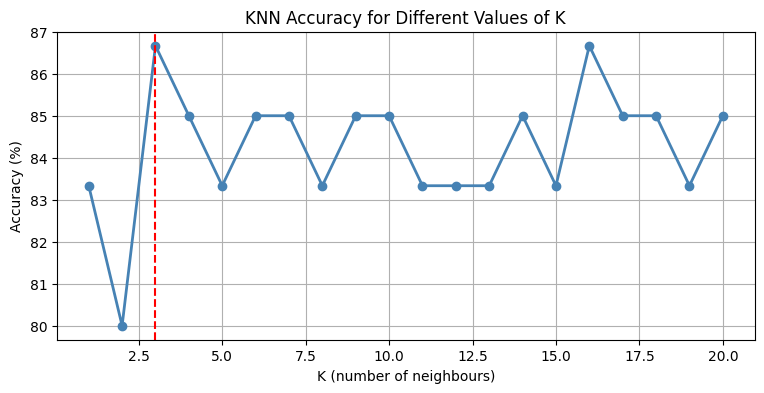

Best K value : 3
Best accuracy: 86.7%


In [ ]:
# Try K values from 1 to 20 and record the accuracy for each
k_values    = list(range(1, 21))
accuracies  = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    preds = knn_k.predict(X_test_scaled)
    acc   = accuracy_score(y_test, preds)
    accuracies.append(acc * 100)

# Find the best K
best_k   = k_values[accuracies.index(max(accuracies))]
best_acc = max(accuracies)

plt.figure(figsize=(9, 4))
plt.plot(k_values, accuracies, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5)
plt.title('KNN Accuracy for Different Values of K')
plt.xlabel('K (number of neighbours)')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.show()

print(f'Best K value : {best_k}')
print(f'Best accuracy: {best_acc:.1f}%')

In [ ]:
# Retrain KNN with the best K
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print(f'KNN model retrained with K = {best_k}')

KNN model retrained with K = 3


---
---
# STEP 4: Decision Tree Classifier

## What Is a Decision Tree?

A Decision Tree learns a series of **if-then-else rules** from the data —  
exactly the way a human loan officer might think.

> 🏦 **The idea in plain English:**  
> The model looks at the data and figures out the most useful questions to ask:  
> - *"Is the credit score above 600?"* → If YES, lean towards Approved. If NO, lean towards Rejected.  
> - *"Is income above 300,000 RWF?"* → If YES, more likely Approved. If NO, look at loan amount.  
> - And so on...
>
> The model automatically figures out the BEST questions and the BEST thresholds  
> by learning from the training data.

**Key advantage over KNN:** Decision Trees do NOT need standardisation (scaling).  
They work with the original numbers because they just ask "is it above/below this threshold?"  
Scaling the numbers would not change those comparisons.

In [ ]:
# Create and train the Decision Tree
# max_depth=4 limits the tree to 4 levels — prevents it from memorising training data
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)   # Note: NO scaling needed for Decision Trees!

print('Decision Tree trained!')

# Make predictions
y_pred_tree = tree_model.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f'Decision Tree Accuracy: {accuracy_tree * 100:.1f}%')

## 4.1 See the Rules the Tree Learned

In [ ]:
# Print the decision rules the tree learned in text format
# This is one of the biggest advantages of Decision Trees — you can READ the logic!
tree_rules = export_text(tree_model, feature_names=feature_columns)
print('Rules learned by the Decision Tree:')
print('(Each |--- is one level deeper in the tree)')
print()
print(tree_rules)

### 💡 Reading the Decision Tree Rules

The tree shows a series of yes/no questions:

- `|--- CreditScore <= 560` → If credit score is 560 or less, go left
- `|   |--- MonthlyIncome <= 300000` → If income is also low, likely Rejected
- `|--- CreditScore > 560` → If credit score is above 560, go right → likely Approved

At the end of each branch is a **class** (0 = Rejected, 1 = Approved).

> 📌 **This is extremely valuable in a banking context!**  
> A loan officer can look at these rules and say:  
> *"The model rejected this application because the credit score was below 560 AND the income was below 300,000."*  
> The customer gets a clear, explainable reason — not just a black-box answer.
>
> This **explainability** is one reason Decision Trees are widely used in banking and finance.

## 4.2 Feature Importance — What Did the Tree Think Mattered Most?

After training, a Decision Tree tells us which features it used most to make decisions.  
This is called **feature importance**.

In [ ]:
# Get feature importances from the trained tree
importances = tree_model.feature_importances_

# Sort from most to least important
importance_df = pd.DataFrame({
    'Feature'   : feature_columns,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='steelblue', edgecolor='white')
plt.title('Feature Importance — Decision Tree\n(How much each feature influenced decisions)')
plt.xlabel('Importance Score (higher = more important)')
plt.tight_layout()
plt.show()

print('Feature importance ranking:')
for _, row in importance_df.sort_values('Importance', ascending=False).iterrows():
    bar = '█' * int(row['Importance'] * 30)
    print(f"  {row['Feature']:<16}  {row['Importance']:.4f}  {bar}")

### 💡 Reading Feature Importance

- **High importance** → the model relied heavily on this feature to make decisions
- **Near zero importance** → the model barely used this feature at all

Features with very low importance could be removed from the model (fewer features = simpler model).  
This matches what we found in Step 2 — the features that looked most different between  
Approved and Rejected groups should have the highest importance scores.

---
### ✏️ YOUR TURN — Steps 3 & 4

1. Try training a KNN model with `n_neighbors=1`. What accuracy do you get?  
   Why is K=1 usually a bad idea? (Think: what happens if one training example has bad data?)

2. Try training a Decision Tree with `max_depth=2` instead of 4. Does accuracy go up or down?  
   Why would a shallower tree (fewer questions) sometimes be better?

3. Try training a Decision Tree with `max_depth=10`. What happens to training accuracy vs test accuracy?  
   This is a famous problem called **overfitting** — look it up in your notes!

In [ ]:
# Task 1: KNN with K=1


# Task 2: Decision Tree with max_depth=2


# Task 3: Decision Tree with max_depth=10 — compare train vs test accuracy
# Hint: use tree_model.score(X_train, y_train) for training accuracy


---
---
# STEP 5: Model Evaluation
### *Accuracy alone is NOT enough — you need to understand the errors*

In regression, we measured MAE and R².  
In classification, we use different metrics:

| Metric | What it measures |
|--------|------------------|
| **Accuracy** | What percentage of all predictions were correct? |
| **Confusion Matrix** | A table showing exactly which types of errors were made |
| **Precision** | Of all the loans the model SAID would be approved, how many actually were? |
| **Recall** | Of all the loans that ACTUALLY should be approved, how many did the model catch? |
| **F1 Score** | A single number combining Precision and Recall |

---

## 5.1 The Confusion Matrix — Understanding Errors in Detail

The **confusion matrix** is a 2×2 table showing all four possible outcomes:

| | Model says: Approved | Model says: Rejected |
|--|--|--|
| **Actually: Approved** | ✅ True Positive (TP) | ❌ False Negative (FN) |
| **Actually: Rejected** | ❌ False Positive (FP) | ✅ True Negative (TN) |

- **True Positive (TP):** Model said Approved → actually Approved ✅ (correct)
- **True Negative (TN):** Model said Rejected → actually Rejected ✅ (correct)
- **False Positive (FP):** Model said Approved → actually Rejected ❌ (bank loses money — gave loan to bad applicant)
- **False Negative (FN):** Model said Rejected → actually Approved ❌ (missed a good customer)

> 🏦 **In banking, these two errors have VERY DIFFERENT costs:**  
> - A **False Positive** = we gave a loan to someone who should not have received it → risk of default → bank loses money  
> - A **False Negative** = we rejected a good customer → they go to a competitor → lost business
>
> Accuracy treats both errors as equally bad. **In reality, they are not.**

In [ ]:
# Confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

print('Confusion Matrix — KNN Model:')
print()
print('                    Model Predicts')
print('                  Rejected  Approved')
print(f'Actually Rejected     {cm_knn[0][0]:>3}       {cm_knn[0][1]:>3}')
print(f'Actually Approved     {cm_knn[1][0]:>3}       {cm_knn[1][1]:>3}')
print()
print(f'True Negatives  (TN) = {cm_knn[0][0]}  ← correctly rejected')
print(f'False Positives (FP) = {cm_knn[0][1]}  ← said Approved but actually Rejected (risky!)')
print(f'False Negatives (FN) = {cm_knn[1][0]}  ← said Rejected but actually Approved (missed)')
print(f'True Positives  (TP) = {cm_knn[1][1]}  ← correctly approved')

In [ ]:
# Draw the confusion matrix as a chart (easier to read visually)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

def draw_confusion_matrix(ax, cm, title):
    labels = [['TN', 'FP'], ['FN', 'TP']]
    colors = [['lightcoral', 'lightyellow'], ['lightyellow', 'lightblue']]
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                         facecolor=colors[i][j], edgecolor='white', linewidth=3))
            ax.text(j + 0.5, 1.5 - i, str(cm[i][j]),
                    ha='center', va='center', fontsize=22, fontweight='bold')
            ax.text(j + 0.5, 1.15 - i, labels[i][j],
                    ha='center', va='center', fontsize=11, color='grey')
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['Pred: Rejected', 'Pred: Approved'])
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Actual: Approved', 'Actual: Rejected'])
    ax.set_title(title, fontweight='bold', pad=12)

draw_confusion_matrix(axes[0], cm_knn,                       f'KNN (K={best_k})')
draw_confusion_matrix(axes[1], confusion_matrix(y_test, y_pred_tree), 'Decision Tree')

plt.tight_layout()
plt.show()

## 5.2 Precision and Recall

These two metrics look at prediction quality from **different angles**:

```
Precision = TP / (TP + FP)
```
> *"Of all the ones I predicted as Approved — how many actually were Approved?"*  
> High precision = when we say Approved, we are usually right.

```
Recall = TP / (TP + FN)
```
> *"Of all the applicants who SHOULD have been Approved — how many did I correctly identify?"*  
> High recall = we catch most of the real positives.

---

**The Precision-Recall trade-off:**

> 🏦 **For a bank, which matters more — Precision or Recall?**  
> - If the bank worries most about **giving loans to bad customers** (losses) → prioritise **Precision**  
> - If the bank worries most about **losing good customers** (missed revenue) → prioritise **Recall**  
>
> You cannot maximise both at the same time — improving one usually hurts the other.

In [ ]:
# Full classification report for KNN
print('KNN Classification Report:')
print(classification_report(y_test, y_pred_knn, target_names=['Rejected', 'Approved']))

In [ ]:
# Full classification report for Decision Tree
print('Decision Tree Classification Report:')
print(classification_report(y_test, y_pred_tree, target_names=['Rejected', 'Approved']))

### 💡 Reading the Classification Report

| Column | What it means |
|--------|---------------|
| `precision` | Of everything predicted as this class, how many were actually this class? |
| `recall` | Of everything that ACTUALLY belongs to this class, how many were correctly predicted? |
| `f1-score` | A single combined score (balance of precision and recall) |
| `support` | How many actual examples of this class were in the test set |

- **Row 0 (Rejected):** How well does the model identify rejections?
- **Row 1 (Approved):** How well does the model identify approvals?
- **macro avg:** Simple average of both rows
- **weighted avg:** Average weighted by how many examples each class has

## 5.3 Side-by-Side Comparison: KNN vs Decision Tree

In [ ]:
# Calculate all metrics for both models
from sklearn.metrics import precision_score, recall_score, f1_score

acc_knn   = accuracy_score(y_test, y_pred_knn)
acc_tree  = accuracy_score(y_test, y_pred_tree)

prec_knn  = precision_score(y_test, y_pred_knn)
prec_tree = precision_score(y_test, y_pred_tree)

rec_knn   = recall_score(y_test, y_pred_knn)
rec_tree  = recall_score(y_test, y_pred_tree)

f1_knn    = f1_score(y_test, y_pred_knn)
f1_tree   = f1_score(y_test, y_pred_tree)

print('=' * 55)
print('     COMPLETE MODEL COMPARISON')
print('=' * 55)
print(f'{"Metric":<14}  {"KNN":>12}  {"Decision Tree":>14}')
print('-' * 55)
print(f'{"Accuracy":<14}  {acc_knn*100:>11.1f}%  {acc_tree*100:>13.1f}%')
print(f'{"Precision":<14}  {prec_knn*100:>11.1f}%  {prec_tree*100:>13.1f}%')
print(f'{"Recall":<14}  {rec_knn*100:>11.1f}%  {rec_tree*100:>13.1f}%')
print(f'{"F1 Score":<14}  {f1_knn*100:>11.1f}%  {f1_tree*100:>13.1f}%')
print('=' * 55)

# Which model wins?
if f1_knn > f1_tree:
    print('KNN has a better F1 Score overall.')
elif f1_tree > f1_knn:
    print('Decision Tree has a better F1 Score overall.')
else:
    print('Both models perform similarly.')

In [ ]:
# Bar chart comparing both models
metrics       = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
knn_scores    = [acc_knn, prec_knn, rec_knn, f1_knn]
tree_scores   = [acc_tree, prec_tree, rec_tree, f1_tree]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], [s*100 for s in knn_scores],
        width=width, color='steelblue', label=f'KNN (K={best_k})', edgecolor='white')
plt.bar([i + width/2 for i in x], [s*100 for s in tree_scores],
        width=width, color='coral', label='Decision Tree', edgecolor='white')

plt.title('Model Comparison: KNN vs Decision Tree')
plt.ylabel('Score (%)')
plt.xticks(list(x), metrics)
plt.ylim(0, 110)
plt.legend()

# Add value labels on bars
for i, (ks, ts) in enumerate(zip(knn_scores, tree_scores)):
    plt.text(i - width/2, ks*100 + 1.5, f'{ks*100:.1f}', ha='center', fontsize=9, fontweight='bold')
    plt.text(i + width/2, ts*100 + 1.5, f'{ts*100:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
### ✏️ YOUR TURN — Step 5

1. Look at the confusion matrix for the Decision Tree.  
   How many **False Positives** are there? What does this mean in banking terms?  
   How many **False Negatives**? What is the business cost of these?

2. From the classification report, which class (Approved or Rejected) does the KNN model predict **more accurately**?  
   Look at the F1 Score for each class.

3. If the bank's priority is to **avoid giving loans to bad customers** (minimise False Positives),  
   should they choose the model with higher **Precision** or higher **Recall**?  
   Which model would you recommend to this bank?

In [ ]:
# Task 1: Read the confusion matrix numbers
cm_tree = confusion_matrix(y_test, y_pred_tree)
print('Decision Tree Confusion Matrix:')
print(f'  False Positives (gave loan to bad applicant) : {cm_tree[0][1]}')
print(f'  False Negatives (rejected good applicant)    : {cm_tree[1][0]}')
# Add your interpretation below as a comment:


# Task 2: Check class-level F1 in classification report (run cell c27 or c28 again)


# Task 3: Your recommendation (write as a comment)
# My recommendation:


---
---
# STEP 6: Predict the Outcome for a New Application

The models are trained and evaluated.  
Now let us use them for their real purpose — predicting outcomes for **new applicants** the model has never seen.

> 🏦 **Scenario:**  
> A new customer walks into the bank. Here are their details:
> - Age: 34 years old
> - Monthly Income: 480,000 RWF
> - Loan Amount Requested: 2,000,000 RWF
> - Employed for: 6 years
> - Credit Score: 650
> - Dependants: 1
> - Has savings account: Yes (1)
>
> **Should the bank approve this loan?**

In [ ]:
# Create the new applicant as a DataFrame
# Column order must match exactly what we used to train the model

new_applicant = pd.DataFrame({
    'CreditScore'  : [650],
    'MonthlyIncome': [480000],
    'LoanAmount'   : [2000000],
    'EmployedYears': [6],
    'LoanToIncome' : [2000000 / (480000 * 12)],  # calculate the ratio
    'HasSavings'   : [1],
    'Dependants'   : [1],
})

print('New applicant profile:')
print(new_applicant)
print()
print(f'Loan-to-Income ratio: {new_applicant["LoanToIncome"].values[0]:.3f}')

In [ ]:
# Predict using the Decision Tree (no scaling needed)
prediction_tree = tree_model.predict(new_applicant)[0]

# Predict using KNN (must scale first using the SAME scaler we used in training)
new_applicant_scaled  = scaler.transform(new_applicant)
prediction_knn        = knn_model.predict(new_applicant_scaled)[0]

# Convert 0/1 to readable labels
label_map = {1: '✅ APPROVED', 0: '❌ REJECTED'}

print('=' * 45)
print('  LOAN DECISION FOR NEW APPLICANT')
print('=' * 45)
print(f'  KNN Prediction          : {label_map[prediction_knn]}')
print(f'  Decision Tree Prediction: {label_map[prediction_tree]}')
print('=' * 45)

if prediction_knn == prediction_tree:
    print('  Both models AGREE on the decision.')
else:
    print('  The models DISAGREE — a human should review this case.')

In [ ]:
# Get the probability of approval from each model (not just Yes/No)
# .predict_proba() returns [probability of Rejected, probability of Approved]

prob_knn  = knn_model.predict_proba(new_applicant_scaled)[0]
prob_tree = tree_model.predict_proba(new_applicant)[0]

print('Probability breakdown:')
print()
print(f'  KNN model:')
print(f'    Probability of Rejection: {prob_knn[0]*100:.1f}%')
print(f'    Probability of Approval : {prob_knn[1]*100:.1f}%')
print()
print(f'  Decision Tree:')
print(f'    Probability of Rejection: {prob_tree[0]*100:.1f}%')
print(f'    Probability of Approval : {prob_tree[1]*100:.1f}%')
print()
print('A probability shows HOW CONFIDENT the model is, not just its final answer.')
print('A 51% approval is much less certain than a 95% approval.')

### 💡 Why Probabilities Matter

A simple Yes/No answer hides important information.  
Knowing the model is **55% confident** of Approval is very different from **95% confident**.

In real banking systems:
- If probability of Approval > 80% → **auto-approve**
- If probability of Approval between 40-80% → **send to human review**
- If probability of Approval < 40% → **auto-reject**

This is how machine learning is actually deployed in banks — not as a complete replacement for human judgment, but as a **first filter** that handles the easy cases automatically.

In [ ]:
# What if the same person had a LOWER credit score?
risky_applicant = pd.DataFrame({
    'CreditScore'  : [420],     # much lower credit score
    'MonthlyIncome': [480000],
    'LoanAmount'   : [2000000],
    'EmployedYears': [6],
    'LoanToIncome' : [2000000 / (480000 * 12)],
    'HasSavings'   : [1],
    'Dependants'   : [1],
})

risky_scaled = scaler.transform(risky_applicant)

pred_risky_knn  = label_map[knn_model.predict(risky_scaled)[0]]
pred_risky_tree = label_map[tree_model.predict(risky_applicant)[0]]

prob_risky = tree_model.predict_proba(risky_applicant)[0]

print('Same applicant but Credit Score = 420 (poor):')
print(f'  KNN:           {pred_risky_knn}')
print(f'  Decision Tree: {pred_risky_tree}')
print(f'  Tree confidence of Approval: {prob_risky[1]*100:.1f}%')

---
### ✏️ YOUR TURN — Step 6

1. Create a new applicant with **your own made-up values** and predict whether their loan would be approved. Try to create:
   - A "clearly strong" applicant (high income, high credit score, low loan amount)
   - A "clearly weak" applicant (low income, low credit score, high loan amount)

2. What is the minimum `CreditScore` needed for the Decision Tree to predict Approval (all other values fixed)?  
   Try changing just the CreditScore from 400 to 800 in steps of 50 and see when the prediction changes.

3. Does having `HasSavings = 1` vs `HasSavings = 0` change the prediction for the original applicant?  
   Test both and compare the probabilities.

In [ ]:
# Task 1: Create and predict for your own applicant(s)
strong_applicant = pd.DataFrame({
    'CreditScore'  : [780],    # change this!
    'MonthlyIncome': [700000], # change this!
    'LoanAmount'   : [1000000],# change this!
    'EmployedYears': [12],     # change this!
    'LoanToIncome' : [1000000 / (700000 * 12)],
    'HasSavings'   : [1],
    'Dependants'   : [0],
})
# pred = tree_model.predict(strong_applicant)[0]
# print('Strong applicant:', label_map[pred])


# Task 2: Find the credit score threshold


# Task 3: Effect of savings


---
---
# 📋 Summary: Everything You Learned

---

### The Classification Process — Always the Same Steps

```
1. Load data and explore it
        ↓
2. Find which features separate the classes
        ↓
3. Split into 80% Training / 20% Test
        ↓
4. (If using KNN) Standardise the features
        ↓
5. Train the model → model.fit(X_train, y_train)
        ↓
6. Evaluate on TEST set → model.predict(X_test)
        ↓
7. Check Accuracy, Confusion Matrix, Precision, Recall
        ↓
8. Predict for new, unseen data
```

---

### The Two Algorithms You Learned

| | KNN | Decision Tree |
|--|--|--|
| **Idea** | Find the K most similar past examples → majority vote | Learn a series of if-then-else rules from the data |
| **Needs scaling?** | ✅ YES — features must be standardised | ❌ NO — works with original numbers |
| **Explainable?** | ❌ Hard to explain WHY it made a decision | ✅ Yes — you can read the rules |
| **Key parameter** | K (number of neighbours) | max_depth (how many questions the tree can ask) |
| **Best for** | When similar examples should have similar outcomes | When you need to explain decisions to humans |

---

### The 4 Evaluation Metrics

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Accuracy** | (TP+TN) / Total | % of all predictions that were correct |
| **Precision** | TP / (TP+FP) | Of predicted Approved, how many really were? |
| **Recall** | TP / (TP+FN) | Of actual Approved, how many did we catch? |
| **F1 Score** | 2×(P×R)/(P+R) | Balance of Precision and Recall |

---

### The sklearn Code Pattern — Classification

```python
# 1. Choose features and target
X = df[['feature1', 'feature2', 'feature3']]
y = df['target']   # 0 or 1 (the two classes)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train
model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

# 4. Predict and evaluate
y_pred = model.predict(X_test)
print('Accuracy  :', accuracy_score(y_test, y_pred))
print('Report:\n', classification_report(y_test, y_pred))
print('Confusion:\n', confusion_matrix(y_test, y_pred))
```

---

### Key Concepts

| Concept | Meaning |
|---------|--------|
| **Classification** | Predicting which CATEGORY something belongs to |
| **Class** | One of the possible categories (e.g. Approved / Rejected) |
| **Class imbalance** | When one class is much more common than the other (accuracy becomes misleading) |
| **True Positive** | Predicted Approved → Actually Approved (correct) |
| **False Positive** | Predicted Approved → Actually Rejected (costly error!) |
| **False Negative** | Predicted Rejected → Actually Approved (missed opportunity) |
| **Overfitting** | Model works perfectly on training data but fails on new data |
| **Scaling** | Making all features have similar ranges (required for KNN) |
| **Feature Importance** | Which features matter most to the model's decisions |

---
**End of Classification Lab** 🎓

---
---
# 🔑 Answer Key

In [ ]:
print('STEP 1 ANSWERS')
print('=' * 40)
stats = df.describe()
print('1. Average CreditScore :', round(stats.loc['mean', 'CreditScore'], 1))
print('2. Average MonthlyIncome:', round(stats.loc['mean', 'MonthlyIncome'], 0), 'RWF')
print('3. Applicants with savings:', df['HasSavings'].sum())

In [ ]:
print('STEP 2 ANSWERS')
print('=' * 40)

# Task 1: LoanToIncome histogram
app_lti = df[df['Approved']==1]['LoanToIncome']
rej_lti = df[df['Approved']==0]['LoanToIncome']
plt.figure(figsize=(9, 4))
plt.hist(app_lti, bins=20, color='steelblue', alpha=0.6, label='Approved', edgecolor='white')
plt.hist(rej_lti, bins=20, color='coral',     alpha=0.6, label='Rejected', edgecolor='white')
plt.title('Loan-to-Income Ratio: Approved vs Rejected')
plt.xlabel('Loan to Income Ratio')
plt.ylabel('Number of Applicants')
plt.legend()
plt.show()
print(f'Average LoanToIncome — Approved: {app_lti.mean():.3f}')
print(f'Average LoanToIncome — Rejected: {rej_lti.mean():.3f}')
print('Lower ratio = safer for the bank = more likely approved')

# Task 2: Savings approval rate
print()
print('2. Approval rate by savings:')
print(df.groupby('HasSavings')['Approved'].mean().mul(100).round(1))
print('   0 = no savings, 1 = has savings')

# Task 3: Employment years by outcome
print()
print('3. Average EmployedYears by outcome:')
print(df.groupby('ApprovalStatus')['EmployedYears'].mean().round(1))

In [ ]:
print('STEPS 3 & 4 ANSWERS')
print('=' * 40)

# Task 1: KNN with K=1
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_scaled, y_train)
acc1 = accuracy_score(y_test, knn1.predict(X_test_scaled))
print(f'1. KNN K=1 accuracy: {acc1*100:.1f}%')
print('   K=1 is risky — it copies the single nearest neighbour.')
print('   If that one neighbour was a data error, the prediction is wrong.')
print('   It often overfits: very high training accuracy, lower test accuracy.')

# Task 2: Shallow tree
tree2 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree2.fit(X_train, y_train)
acc2 = accuracy_score(y_test, tree2.predict(X_test))
print(f'\n2. Decision Tree max_depth=2 accuracy: {acc2*100:.1f}%')
print('   Shallower tree = simpler rules = may be more general = sometimes better on new data')

# Task 3: Deep tree — overfitting demo
tree10 = DecisionTreeClassifier(max_depth=10, random_state=42)
tree10.fit(X_train, y_train)
train_acc = tree10.score(X_train, y_train)
test_acc  = accuracy_score(y_test, tree10.predict(X_test))
print(f'\n3. Decision Tree max_depth=10:')
print(f'   Training accuracy: {train_acc*100:.1f}%')
print(f'   Test accuracy    : {test_acc*100:.1f}%')
print('   The gap between training (high) and test (lower) = OVERFITTING!')
print('   The model memorised the training data but does not generalise.')

In [ ]:
print('STEP 6 ANSWERS')
print('=' * 40)

# Task 2: Find credit score threshold
print('2. Finding credit score threshold for Decision Tree approval:')
base = {'MonthlyIncome':[480000],'LoanAmount':[2000000],'EmployedYears':[6],
        'LoanToIncome':[2000000/(480000*12)],'HasSavings':[1],'Dependants':[1]}

for score in range(400, 801, 50):
    test_app = pd.DataFrame({'CreditScore':[score], **base})
    pred = tree_model.predict(test_app)[0]
    prob = tree_model.predict_proba(test_app)[0][1]
    print(f'   CreditScore {score}: {label_map[pred]}  (approval prob: {prob*100:.0f}%)')

# Task 3: Effect of savings
print()
print('3. Effect of savings (Credit Score = 650, everything else same):')
for sav in [0, 1]:
    app = pd.DataFrame({'CreditScore':[650],'MonthlyIncome':[480000],
                        'LoanAmount':[2000000],'EmployedYears':[6],
                        'LoanToIncome':[2000000/(480000*12)],
                        'HasSavings':[sav],'Dependants':[1]})
    pred = tree_model.predict(app)[0]
    prob = tree_model.predict_proba(app)[0][1]
    label = 'Has savings' if sav == 1 else 'No savings'
    print(f'   {label}: {label_map[pred]}  (approval probability: {prob*100:.1f}%)')